# Salience Trend Audit

This notebook analyses annual source-year Salience from the completed Common Crawl trend run. The primary measure is WARC-validated ADHD/autism hits per million minimum-length WET tokens. This is a source-year salience measure, unlike the later semantic LSC analyses, which use publication year.

The report-facing output is deliberately compact: one primary trajectory figure, source-year trend tables, and short caveat tables for publication-year composition and raw-form balance.


## Setup

The input contract is restricted to the two processed trend outputs. Tables are written to the ignored processed-analysis directory; report-ready figures are exported as PNG and PDF.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "05_salience":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

TREND_DIR = PROJECT_ROOT / "data/processed/trend"
TREND_RATES_PATH = TREND_DIR / "trend_rates.csv"
PUBLICATION_DIAGNOSTICS_PATH = TREND_DIR / "trend_publication_year_diagnostics.csv"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/lsc/salience"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/lsc/salience"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_YEARS = list(range(2014, 2027))
EARLY_YEARS = [2014, 2015, 2016]
LATE_YEARS = [2024, 2025, 2026]
TARGET_UNITS = ["ADHD", "Autism"]
BASELINE_UNITS = ["frustration", "loneliness", "sadness"]
ANALYSIS_UNITS = TARGET_UNITS + BASELINE_UNITS
DW_AUTOCORRELATION_LOW = 1.25
DW_AUTOCORRELATION_HIGH = 2.75

COLOURS = {
    "ADHD": "#2F6F9F",
    "Autism": "#B66A4A",
    "frustration": "#4F8F78",
    "loneliness": "#7FA68A",
    "sadness": "#9AA6A1",
}
MARKERS = {"ADHD": "o", "Autism": "s", "frustration": "^", "loneliness": "D", "sadness": "v"}

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#263238",
        "axes.labelcolor": "#263238",
        "axes.titlecolor": "#263238",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#D7DEE2",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "legend.frameon": False,
        "xtick.color": "#263238",
        "ytick.color": "#263238",
    }
)

def save_figure(figure: plt.Figure, stem: str) -> None:
    figure.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    figure.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

for path in [TREND_RATES_PATH, PUBLICATION_DIAGNOSTICS_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required trend output: {path.relative_to(PROJECT_ROOT)}")


## Load and Audit the Trend Contract

The audit checks annual coverage, denominator consistency, validation-stage ordering, and whether matched target forms sum exactly to their target-group totals. The primary Salience denominator is the annual minimum-length WET token count, so all substantive trajectory interpretation remains tied to Common Crawl source year.


In [2]:
trend_rates = pd.read_csv(TREND_RATES_PATH)
publication_diagnostics = pd.read_csv(PUBLICATION_DIAGNOSTICS_PATH)

required_rate_columns = {
    "year", "source_year", "temporal_axis", "primary_denominator", "aggregation_level",
    "term_role", "term_group", "matched_term", "tokens_minlen", "candidate_hits",
    "validated_hits_wet", "validated_hits_warc", "candidate_hits_per_million_minlen_tokens",
    "wet_salience_per_million_minlen_tokens", "primary_salience_per_million_tokens",
    "warc_over_wet_validation_rate", "pct_warc_validated_docs_with_published_ts",
}
missing_rate_columns = sorted(required_rate_columns - set(trend_rates.columns))
if missing_rate_columns:
    raise ValueError(f"Missing trend-rate columns: {missing_rate_columns}")

all_rows = trend_rates.loc[trend_rates["aggregation_level"].eq("all")].copy()
matched_target_rows = trend_rates.loc[
    trend_rates["aggregation_level"].eq("matched_term") & trend_rates["term_role"].eq("target")
].copy()
target_group_rows = trend_rates.loc[
    trend_rates["aggregation_level"].eq("term_group") & trend_rates["term_role"].eq("target")
].copy()

raw_form_sums = matched_target_rows.groupby(["year", "term_group"], as_index=False)[
    ["candidate_hits", "validated_hits_wet", "validated_hits_warc"]
].sum()
group_counts = target_group_rows[["year", "term_group", "candidate_hits", "validated_hits_wet", "validated_hits_warc"]]
sum_check = group_counts.merge(raw_form_sums, on=["year", "term_group"], suffixes=("_group", "_raw_sum"))
sum_check_ok = all(
    np.allclose(sum_check[f"{column}_group"], sum_check[f"{column}_raw_sum"])
    for column in ["candidate_hits", "validated_hits_wet", "validated_hits_warc"]
)

checks = pd.DataFrame([
    {"check": "expected_source_years", "status": "pass" if sorted(trend_rates["year"].unique()) == EXPECTED_YEARS else "fail", "detail": str([int(year) for year in sorted(trend_rates["year"].unique())])},
    {"check": "source_year_axis", "status": "pass" if set(trend_rates["temporal_axis"]) == {"source_year"} else "fail", "detail": str(sorted(trend_rates["temporal_axis"].unique()))},
    {"check": "minimum_length_token_denominator", "status": "pass" if set(trend_rates["primary_denominator"]) == {"tokens_minlen"} else "fail", "detail": str(sorted(trend_rates["primary_denominator"].unique()))},
    {"check": "validation_counts_monotonic", "status": "pass" if ((trend_rates["candidate_hits"] >= trend_rates["validated_hits_wet"]) & (trend_rates["validated_hits_wet"] >= trend_rates["validated_hits_warc"])).all() else "fail", "detail": "candidate >= WET validated >= WARC validated"},
    {"check": "raw_forms_sum_to_target_groups", "status": "pass" if sum_check_ok else "fail", "detail": "matched target forms reproduce group-level counts"},
    {"check": "publication_timestamp_coverage", "status": "pass" if all_rows["pct_warc_validated_docs_with_published_ts"].min() >= 95 else "warn", "detail": f"minimum={all_rows['pct_warc_validated_docs_with_published_ts'].min():.2f}%"},
    {"check": "domain_concentration", "status": "not_available", "detail": "processed trend handoff has no domain-level counts; fixed collection domain cap=50 still applies"},
])
checks.to_csv(OUTPUT_DIR / "salience_audit_checks.csv", index=False)

denominator_audit = all_rows[[
    "year", "docs_scanned", "docs_minlen", "tokens_scanned", "tokens_minlen",
    "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "pct_fetch_success_docs_with_published_ts", "pct_warc_validated_docs_with_published_ts",
]].copy()
denominator_audit.to_csv(OUTPUT_DIR / "salience_denominator_audit.csv", index=False)

display(checks)
display(denominator_audit)


,check,status,detail
0,expected_source_years,pass,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202..."
1,source_year_axis,pass,['source_year']
2,minimum_length_token_denominator,pass,['tokens_minlen']
3,validation_counts_monotonic,pass,candidate >= WET validated >= WARC validated
4,raw_forms_sum_to_target_groups,pass,matched target forms reproduce group-level counts
5,publication_timestamp_coverage,pass,minimum=96.06%
6,domain_concentration,not_available,processed trend handoff has no domain-level co...


,year,docs_scanned,docs_minlen,tokens_scanned,tokens_minlen,candidate_hits,validated_hits_wet,validated_hits_warc,pct_fetch_success_docs_with_published_ts,pct_warc_validated_docs_with_published_ts
0,2014,5349060.0,3762398.0,3.483619e+09,3.439498e+09,57128.0,29182.0,13918.0,98.051083,97.347595
15,2015,5291648.0,3632797.0,3.470904e+09,3.426098e+09,49619.0,25203.0,11898.0,98.064335,97.077497
30,2016,5760599.0,5329183.0,5.722869e+09,5.709595e+09,85600.0,40044.0,19945.0,98.426011,97.575085
45,2017,4435233.0,4231720.0,4.633506e+09,4.626729e+09,51233.0,25351.0,11828.0,98.033668,97.200861
60,2018,4702862.0,4429927.0,4.326587e+09,4.316886e+09,45638.0,26406.0,12086.0,98.229411,97.506285
75,2019,4377625.0,4099485.0,4.100525e+09,4.091312e+09,42410.0,28262.0,13847.0,97.190097,96.059658
90,2020,5040987.0,4785776.0,5.392948e+09,5.383636e+09,53444.0,32802.0,14117.0,97.900670,97.359794
105,2021,4818457.0,4556751.0,4.847258e+09,4.837622e+09,46689.0,30804.0,13996.0,98.260558,98.121324
120,2022,4217647.0,3870995.0,4.027739e+09,4.017628e+09,39809.0,26183.0,11948.0,98.552681,98.307159
135,2023,3806981.0,3525612.0,3.585727e+09,3.577251e+09,33691.0,21098.0,10102.0,98.573417,98.445847


## Construct Main Analysis Units

The main table uses target-group totals for ADHD and Autism and matched-term totals for each comparator. `relative_to_2014` is retained only to compare trajectory shape across terms with different absolute frequencies; it does not replace the absolute per-million-token Salience measure.


In [3]:
target_units = target_group_rows.copy()
target_units["analysis_unit"] = target_units["term_group"].map({"adhd": "ADHD", "autism": "Autism"})

baseline_units = trend_rates.loc[
    trend_rates["aggregation_level"].eq("matched_term") & trend_rates["term_role"].eq("baseline")
].copy()
baseline_units["analysis_unit"] = baseline_units["matched_term"]

unit_year = pd.concat([target_units, baseline_units], ignore_index=True)
unit_year = unit_year.loc[unit_year["analysis_unit"].isin(ANALYSIS_UNITS)].copy()
unit_year["analysis_role"] = np.where(unit_year["analysis_unit"].isin(TARGET_UNITS), "target", "baseline")
unit_year = unit_year.sort_values(["analysis_role", "analysis_unit", "year"]).reset_index(drop=True)
unit_year["wet_over_candidate_validation_rate"] = unit_year["validated_hits_wet"] / unit_year["candidate_hits"]
unit_year["relative_to_2014"] = unit_year["primary_salience_per_million_tokens"] / unit_year.groupby("analysis_unit")["primary_salience_per_million_tokens"].transform("first")

main_columns = [
    "year", "source_year", "analysis_role", "analysis_unit", "tokens_minlen",
    "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "candidate_hits_per_million_minlen_tokens", "wet_salience_per_million_minlen_tokens",
    "primary_salience_per_million_tokens", "relative_to_2014",
    "wet_over_candidate_validation_rate", "warc_over_wet_validation_rate",
    "pct_warc_validated_docs_with_published_ts",
]
unit_year = unit_year[main_columns]
unit_year.to_csv(OUTPUT_DIR / "salience_unit_year.csv", index=False)

if unit_year.groupby("analysis_unit")["year"].nunique().ne(len(EXPECTED_YEARS)).any():
    raise ValueError("At least one main analysis unit lacks a complete annual series.")

display(unit_year.head(15))

,year,source_year,analysis_role,analysis_unit,tokens_minlen,candidate_hits,validated_hits_wet,validated_hits_warc,candidate_hits_per_million_minlen_tokens,wet_salience_per_million_minlen_tokens,primary_salience_per_million_tokens,relative_to_2014,wet_over_candidate_validation_rate,warc_over_wet_validation_rate,pct_warc_validated_docs_with_published_ts
0,2014,2014,baseline,frustration,3.439498e+09,12759.0,8080.0,5079.0,3.709553,2.349180,1.476669,1.000000,0.633278,0.628589,97.347595
1,2015,2015,baseline,frustration,3.426098e+09,11776.0,7292.0,4481.0,3.437146,2.128369,1.307902,0.885711,0.619226,0.614509,97.077497
2,2016,2016,baseline,frustration,5.709595e+09,19410.0,12381.0,7935.0,3.399540,2.168455,1.389766,0.941149,0.637867,0.640901,97.575085
3,2017,2017,baseline,frustration,4.626729e+09,11601.0,6232.0,3947.0,2.507387,1.346956,0.853087,0.577710,0.537195,0.633344,97.200861
4,2018,2018,baseline,frustration,4.316886e+09,9951.0,6045.0,3967.0,2.305134,1.400315,0.918949,0.622312,0.607477,0.656245,97.506285
5,2019,2019,baseline,frustration,4.091312e+09,8863.0,6270.0,4137.0,2.166298,1.532516,1.011167,0.684762,0.707435,0.659809,96.059658
6,2020,2020,baseline,frustration,5.383636e+09,11735.0,7519.0,4444.0,2.179754,1.396640,0.825464,0.559004,0.640733,0.591036,97.359794
7,2021,2021,baseline,frustration,4.837622e+09,9928.0,7269.0,4537.0,2.052248,1.502598,0.937857,0.635117,0.732172,0.624157,98.121324
8,2022,2022,baseline,frustration,4.017628e+09,8282.0,6071.0,3881.0,2.061415,1.511090,0.965993,0.654170,0.733035,0.639269,98.307159
9,2023,2023,baseline,frustration,3.577251e+09,6796.0,4815.0,3410.0,1.899783,1.346006,0.953246,0.645538,0.708505,0.708204,98.445847


## Descriptive Trend Summary

The summary compares 2014–2016 with 2024–2026, estimates a simple linear slope across source years, and records rank-order direction. These are descriptive trajectory summaries, not confirmatory time-series inference.

In [4]:
summary_rows = []
for analysis_unit, frame in unit_year.groupby("analysis_unit", sort=False):
    frame = frame.sort_values("year")
    early_mean = frame.loc[frame["year"].isin(EARLY_YEARS), "primary_salience_per_million_tokens"].mean()
    late_mean = frame.loc[frame["year"].isin(LATE_YEARS), "primary_salience_per_million_tokens"].mean()
    slope = np.polyfit(frame["year"], frame["primary_salience_per_million_tokens"], 1)[0]
    summary_rows.append({
        "analysis_unit": analysis_unit,
        "analysis_role": frame["analysis_role"].iloc[0],
        "early_2014_2016_mean": early_mean,
        "late_2024_2026_mean": late_mean,
        "early_to_late_pct_change": 100 * (late_mean / early_mean - 1),
        "linear_slope_per_year": slope,
        "spearman_year_rate": frame["year"].corr(frame["primary_salience_per_million_tokens"], method="spearman"),
        "minimum_primary_salience": frame["primary_salience_per_million_tokens"].min(),
        "maximum_primary_salience": frame["primary_salience_per_million_tokens"].max(),
        "mean_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].mean(),
        "minimum_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].min(),
        "maximum_warc_over_wet_validation_rate": frame["warc_over_wet_validation_rate"].max(),
        "wet_warc_rate_correlation": frame["wet_salience_per_million_minlen_tokens"].corr(frame["primary_salience_per_million_tokens"]),
    })

trend_summary = pd.DataFrame(summary_rows)
trend_summary.to_csv(OUTPUT_DIR / "salience_trend_summary.csv", index=False)
display(trend_summary.round(4))


def fit_trend_model(frame: pd.DataFrame, value_column: str, year_column: str = "year") -> dict[str, object]:
    data = frame[[year_column, value_column]].dropna().sort_values(year_column)
    if len(data) < 3 or data[value_column].nunique() < 2:
        return {
            "n_years": len(data),
            "year_center": np.nan,
            "linear_intercept": np.nan,
            "linear_slope_per_year": np.nan,
            "linear_slope_se": np.nan,
            "linear_p_value": np.nan,
            "linear_r_squared": np.nan,
            "linear_adj_r_squared": np.nan,
            "standardized_beta_year": np.nan,
            "durbin_watson": np.nan,
            "lag1_residual_autocorrelation": np.nan,
            "autocorrelation_flag": False,
            "ar1_sensitivity_slope_per_year": np.nan,
            "ar1_sensitivity_p_value": np.nan,
            "quadratic_adj_r_squared": np.nan,
            "quadratic_delta_adj_r_squared": np.nan,
        }
    years = data[year_column].to_numpy(dtype=float)
    values = data[value_column].to_numpy(dtype=float)
    year_center = float(years.mean())
    x = years - year_center
    result = stats.linregress(x, values)
    fitted = result.intercept + result.slope * x
    residuals = values - fitted
    sse = float(np.sum(residuals**2))
    sst = float(np.sum((values - values.mean()) ** 2))
    r_squared = 1 - sse / sst if sst else np.nan
    n = len(values)
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - 2) if n > 2 and not np.isnan(r_squared) else np.nan
    std_beta = result.slope * np.std(x, ddof=1) / np.std(values, ddof=1) if np.std(values, ddof=1) else np.nan
    dw_denominator = float(np.sum(residuals**2))
    durbin_watson = float(np.sum(np.diff(residuals) ** 2) / dw_denominator) if dw_denominator else np.nan
    lag1 = float(np.corrcoef(residuals[:-1], residuals[1:])[0, 1]) if n >= 4 and np.std(residuals) else np.nan
    autocorrelation_flag = bool(
        not np.isnan(durbin_watson)
        and (durbin_watson < DW_AUTOCORRELATION_LOW or durbin_watson > DW_AUTOCORRELATION_HIGH)
    )
    ar1_slope = np.nan
    ar1_p_value = np.nan
    if autocorrelation_flag and n >= 5 and not np.isnan(lag1) and abs(lag1) < 0.98:
        y_star = values[1:] - lag1 * values[:-1]
        x_star = x[1:] - lag1 * x[:-1]
        ar1_result = stats.linregress(x_star, y_star)
        ar1_slope = float(ar1_result.slope)
        ar1_p_value = float(ar1_result.pvalue)
    quadratic_adj_r_squared = np.nan
    quadratic_delta = np.nan
    if n >= 6:
        q_coefficients = np.polyfit(x, values, deg=2)
        q_fitted = np.polyval(q_coefficients, x)
        q_sse = float(np.sum((values - q_fitted) ** 2))
        q_r_squared = 1 - q_sse / sst if sst else np.nan
        quadratic_adj_r_squared = 1 - (1 - q_r_squared) * (n - 1) / (n - 3) if n > 3 and not np.isnan(q_r_squared) else np.nan
        quadratic_delta = quadratic_adj_r_squared - adj_r_squared if not np.isnan(quadratic_adj_r_squared) else np.nan
    return {
        "n_years": n,
        "year_center": year_center,
        "linear_intercept": float(result.intercept),
        "linear_slope_per_year": float(result.slope),
        "linear_slope_se": float(result.stderr) if result.stderr is not None else np.nan,
        "linear_p_value": float(result.pvalue),
        "linear_r_squared": float(r_squared),
        "linear_adj_r_squared": float(adj_r_squared),
        "standardized_beta_year": float(std_beta),
        "durbin_watson": durbin_watson,
        "lag1_residual_autocorrelation": lag1,
        "autocorrelation_flag": autocorrelation_flag,
        "ar1_sensitivity_slope_per_year": ar1_slope,
        "ar1_sensitivity_p_value": ar1_p_value,
        "quadratic_adj_r_squared": quadratic_adj_r_squared,
        "quadratic_delta_adj_r_squared": quadratic_delta,
    }


trend_model_rows = []
for analysis_unit, frame in unit_year.groupby("analysis_unit", sort=True):
    trend_model_rows.append(
        {
            "analysis_unit": analysis_unit,
            "analysis_role": frame["analysis_role"].iloc[0],
            "frame_stratum": "source_year_salience",
            "index_name": "primary_salience_per_million_tokens",
            **fit_trend_model(frame, "primary_salience_per_million_tokens"),
        }
    )
trend_models = pd.DataFrame(trend_model_rows)
trend_models.to_csv(OUTPUT_DIR / "salience_trend_models.csv", index=False)
display(trend_models.round(4))


,analysis_unit,analysis_role,early_2014_2016_mean,late_2024_2026_mean,early_to_late_pct_change,linear_slope_per_year,spearman_year_rate,minimum_primary_salience,maximum_primary_salience,mean_warc_over_wet_validation_rate,minimum_warc_over_wet_validation_rate,maximum_warc_over_wet_validation_rate,wet_warc_rate_correlation
0,frustration,baseline,1.3914,1.1345,-18.4654,-0.0175,-0.0879,0.8255,1.4767,0.6630,0.5910,0.7765,0.9265
1,loneliness,baseline,0.3031,0.3477,14.7130,0.0056,0.6429,0.2566,0.3713,0.5423,0.4905,0.6163,0.8000
2,sadness,baseline,0.6515,0.4441,-31.8274,-0.0171,-0.7418,0.4177,0.6841,0.5922,0.5175,0.7045,0.9094
3,ADHD,target,0.3429,0.4113,19.9636,0.0073,0.4615,0.2808,0.4698,0.3215,0.2889,0.3603,0.9472
4,Autism,target,0.9819,0.7453,-24.0988,-0.0228,-0.5604,0.6808,1.1409,0.3618,0.3374,0.4187,0.9360


,analysis_unit,analysis_role,frame_stratum,index_name,n_years,year_center,linear_intercept,linear_slope_per_year,linear_slope_se,linear_p_value,linear_r_squared,linear_adj_r_squared,standardized_beta_year,durbin_watson,lag1_residual_autocorrelation,autocorrelation_flag,ar1_sensitivity_slope_per_year,ar1_sensitivity_p_value,quadratic_adj_r_squared,quadratic_delta_adj_r_squared
0,ADHD,target,source_year_salience,primary_salience_per_million_tokens,13,2020.0,0.3664,0.0073,0.0043,0.1178,0.2074,0.1354,0.4554,1.8658,-0.1631,False,NaN,NaN,0.1827,0.0473
1,Autism,target,source_year_salience,primary_salience_per_million_tokens,13,2020.0,0.8105,-0.0228,0.0087,0.0240,0.3835,0.3274,-0.6193,1.6744,0.0148,False,NaN,NaN,0.4628,0.1354
2,frustration,baseline,source_year_salience,primary_salience_per_million_tokens,13,2020.0,1.0803,-0.0175,0.0167,0.3180,0.0905,0.0078,-0.3008,0.9254,0.3840,True,0.016,0.5383,0.7252,0.7174
3,loneliness,baseline,source_year_salience,primary_salience_per_million_tokens,13,2020.0,0.3235,0.0056,0.0021,0.0228,0.3889,0.3333,0.6236,2.1678,-0.1605,False,NaN,NaN,0.2672,-0.0661
4,sadness,baseline,source_year_salience,primary_salience_per_million_tokens,13,2020.0,0.5205,-0.0171,0.0039,0.0011,0.6381,0.6052,-0.7988,1.8037,-0.0007,False,NaN,NaN,0.6731,0.0679


## Primary Salience Trajectories

The primary figure has two panels. The left panel shows the absolute Salience result for ADHD and Autism. The right panel indexes each target and comparator term to its own 2014 rate, which helps compare proportional movement without implying that the indexed values are the Salience measure itself.


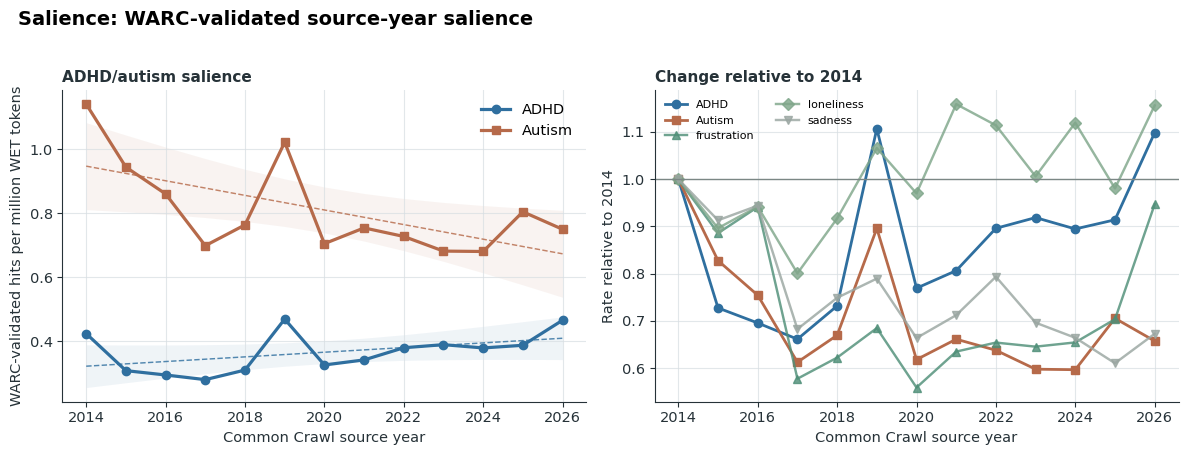

In [5]:
def ols_fit_band(frame: pd.DataFrame, x_column: str, y_column: str, confidence: float = 0.95) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] | None:
    data = frame[[x_column, y_column]].dropna().sort_values(x_column)
    if len(data) < 3 or np.isclose(data[x_column].var(ddof=1), 0):
        return None
    x = data[x_column].to_numpy(dtype=float)
    y = data[y_column].to_numpy(dtype=float)
    x_centered = x - x.mean()
    fit = stats.linregress(x_centered, y)
    fitted = fit.intercept + fit.slope * x_centered
    residual = y - fitted
    dof = len(x) - 2
    sxx = np.sum((x - x.mean()) ** 2)
    if dof <= 0 or np.isclose(sxx, 0):
        return x, fitted, fitted, fitted
    residual_se = np.sqrt(np.sum(residual ** 2) / dof)
    t_crit = stats.t.ppf((1 + confidence) / 2, dof)
    mean_se = residual_se * np.sqrt((1 / len(x)) + ((x - x.mean()) ** 2 / sxx))
    return x, fitted, fitted - t_crit * mean_se, fitted + t_crit * mean_se


def plot_absolute_salience(axis: plt.Axes, frame: pd.DataFrame, unit: str) -> None:
    colour = COLOURS[unit]
    axis.plot(
        frame["year"],
        frame["primary_salience_per_million_tokens"],
        color=colour,
        marker=MARKERS[unit],
        linewidth=2.3,
        label=unit,
    )
    band = ols_fit_band(frame, "year", "primary_salience_per_million_tokens")
    if band is not None:
        x, fitted, low, high = band
        axis.fill_between(x, low, high, color=colour, alpha=0.075, linewidth=0)
        axis.plot(x, fitted, color=colour, linestyle="--", linewidth=1.05, alpha=0.82)


def plot_indexed_salience(axis: plt.Axes, frame: pd.DataFrame, unit: str) -> None:
    axis.plot(
        frame["year"],
        frame["relative_to_2014"],
        color=COLOURS[unit],
        marker=MARKERS[unit],
        linewidth=2.0 if unit in TARGET_UNITS else 1.75,
        alpha=1.0 if unit in TARGET_UNITS else 0.82,
        label=unit,
    )


figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

for unit in TARGET_UNITS:
    plot_absolute_salience(axes[0], unit_year.loc[unit_year["analysis_unit"].eq(unit)], unit)
axes[0].set_title("ADHD/autism salience", loc="left", fontsize=11, fontweight="bold")
axes[0].set_ylabel("WARC-validated hits per million WET tokens")
axes[0].set_xticks(EXPECTED_YEARS[::2])
axes[0].legend(frameon=False)

for unit in ANALYSIS_UNITS:
    plot_indexed_salience(axes[1], unit_year.loc[unit_year["analysis_unit"].eq(unit)], unit)
axes[1].axhline(1, color="#7B8785", linewidth=1)
axes[1].set_title("Change relative to 2014", loc="left", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Rate relative to 2014")
axes[1].set_xticks(EXPECTED_YEARS[::2])
axes[1].legend(frameon=False, fontsize=8, ncol=2)

for axis in axes:
    axis.set_xlabel("Common Crawl source year")
figure.suptitle("Salience: WARC-validated source-year salience", fontsize=14, fontweight="bold", x=0.02, ha="left")
figure.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(figure, "lsc_salience_primary_trajectories")
plt.show()


## Caveat and Diagnostic Tables

The Salience denominator is based on source-year WET scans. Publication-year status is therefore a caveat rather than an alternative denominator. Raw-form balance is retained as a compact diagnostic table so that target-group trends can be checked without adding another report figure.


In [6]:
raw_form_year = matched_target_rows[[
    "year", "term_group", "matched_term", "candidate_hits", "validated_hits_wet", "validated_hits_warc",
    "primary_salience_per_million_tokens", "warc_over_wet_validation_rate",
]].copy()
raw_form_year["analysis_unit"] = raw_form_year["term_group"].map({"adhd": "ADHD", "autism": "Autism"})
raw_form_year["warc_share_within_group"] = raw_form_year["validated_hits_warc"] / raw_form_year.groupby(["year", "analysis_unit"])["validated_hits_warc"].transform("sum")
raw_form_year = raw_form_year.sort_values(["analysis_unit", "matched_term", "year"])
raw_form_year.to_csv(OUTPUT_DIR / "salience_raw_form_year.csv", index=False)

term_publication = publication_diagnostics.loc[publication_diagnostics["diagnostic_level"].eq("term")].copy()
term_publication["analysis_unit"] = np.where(
    term_publication["term_role"].eq("target"),
    term_publication["term_group"].map({"adhd": "ADHD", "autism": "Autism"}),
    term_publication["matched_term"],
)
publication_unit_status = term_publication.loc[term_publication["analysis_unit"].isin(ANALYSIS_UNITS)].groupby(
    ["year", "analysis_unit", "publication_year_status"], as_index=False
)["validated_hits_warc"].sum()
publication_unit_status["status_share"] = publication_unit_status["validated_hits_warc"] / publication_unit_status.groupby(["year", "analysis_unit"])["validated_hits_warc"].transform("sum")
publication_unit_status.to_csv(OUTPUT_DIR / "salience_publication_year_status.csv", index=False)

document_publication = publication_diagnostics.loc[publication_diagnostics["diagnostic_level"].eq("document")].groupby(
    ["year", "publication_year_status"], as_index=False
)[["input_docs", "fetch_success_docs", "warc_validated_docs"]].sum()
document_publication["warc_status_share"] = document_publication["warc_validated_docs"] / document_publication.groupby("year")["warc_validated_docs"].transform("sum")
document_publication.to_csv(OUTPUT_DIR / "salience_publication_year_document_status.csv", index=False)

publication_caveat = publication_unit_status.loc[
    publication_unit_status["analysis_unit"].isin(TARGET_UNITS)
].pivot_table(index=["year", "analysis_unit"], columns="publication_year_status", values="status_share").round(3)
raw_form_caveat = raw_form_year.pivot_table(
    index=["year", "analysis_unit"], columns="matched_term", values="warc_share_within_group"
).round(3)

print("Publication-year status shares for target WARC hits:")
display(publication_caveat)
print("Raw-form shares within target groups:")
display(raw_form_caveat)


Publication-year status shares for target WARC hits:


publication_year_status  before_window  in_window  missing_or_unparseable
year analysis_unit                                                       
2014 ADHD                        0.723      0.259                   0.018
     Autism                      0.668      0.312                   0.020
2015 ADHD                        0.649      0.301                   0.050
     Autism                      0.621      0.362                   0.017
2016 ADHD                        0.590      0.400                   0.009
     Autism                      0.555      0.426                   0.020
2017 ADHD                        0.480      0.498                   0.022
     Autism                      0.440      0.542                   0.018
2018 ADHD                        0.380      0.590                   0.030
     Autism                      0.361      0.619                   0.020
2019 ADHD                        0.362      0.536                   0.101
     Autism                      0.373      0.558                   0.069
2020 ADHD                        0.242      0.734                   0.023
     Autism                      0.274      0.706                   0.020
2021 ADHD                        0.186      0.798                   0.016
     Autism                      0.188      0.792                   0.020
2022 ADHD                        0.156      0.826                   0.018
     Autism                      0.175      0.812                   0.013
2023 ADHD                        0.149      0.840                   0.011
     Autism                      0.144      0.844                   0.012
2024 ADHD                        0.096      0.893                   0.011
     Autism                      0.110      0.880                   0.010
2025 ADHD                        0.098      0.888                   0.014
     Autism                      0.096      0.894                   0.010
2026 ADHD                        0.076      0.913                   0.011
     Autism                      0.101      0.889                   0.011

Raw-form shares within target groups:


matched_term         adhd    asd  attention_deficit  autism  autism_spectrum  \
year analysis_unit                                                             
2014 ADHD           0.733    NaN              0.267     NaN              NaN   
     Autism           NaN  0.053                NaN   0.620            0.141   
2015 ADHD           0.732    NaN              0.268     NaN              NaN   
     Autism           NaN  0.040                NaN   0.614            0.143   
2016 ADHD           0.754    NaN              0.246     NaN              NaN   
     Autism           NaN  0.034                NaN   0.625            0.122   
2017 ADHD           0.766    NaN              0.234     NaN              NaN   
     Autism           NaN  0.045                NaN   0.646            0.125   
2018 ADHD           0.796    NaN              0.204     NaN              NaN   
     Autism           NaN  0.045                NaN   0.625            0.136   
2019 ADHD           0.813    NaN              0.187     NaN              NaN   
     Autism           NaN  0.034                NaN   0.641            0.172   
2020 ADHD           0.822    NaN              0.178     NaN              NaN   
     Autism           NaN  0.043                NaN   0.633            0.154   
2021 ADHD           0.829    NaN              0.171     NaN              NaN   
     Autism           NaN  0.053                NaN   0.609            0.158   
2022 ADHD           0.841    NaN              0.159     NaN              NaN   
     Autism           NaN  0.053                NaN   0.616            0.159   
2023 ADHD           0.822    NaN              0.178     NaN              NaN   
     Autism           NaN  0.047                NaN   0.621            0.174   
2024 ADHD           0.812    NaN              0.188     NaN              NaN   
     Autism           NaN  0.050                NaN   0.616            0.162   
2025 ADHD           0.849    NaN              0.151     NaN              NaN   
     Autism           NaN  0.044                NaN   0.656            0.141   
2026 ADHD           0.852    NaN              0.148     NaN              NaN   
     Autism           NaN  0.055                NaN   0.606            0.168   

matched_term        autistic  
year analysis_unit            
2014 ADHD                NaN  
     Autism            0.186  
2015 ADHD                NaN  
     Autism            0.203  
2016 ADHD                NaN  
     Autism            0.219  
2017 ADHD                NaN  
     Autism            0.183  
2018 ADHD                NaN  
     Autism            0.195  
2019 ADHD                NaN  
     Autism            0.153  
2020 ADHD                NaN  
     Autism            0.171  
2021 ADHD                NaN  
     Autism            0.180  
2022 ADHD                NaN  
     Autism            0.171  
2023 ADHD                NaN  
     Autism            0.159  
2024 ADHD                NaN  
     Autism            0.172  
2025 ADHD                NaN  
     Autism            0.159  
2026 ADHD                NaN  
     Autism            0.171

## Interpretation Handoff

The primary output characterises term salience within sampled Common Crawl source-year slices, not population prevalence or public concern. The indexed comparison panel is useful for proportional comparison with baseline terms, but the absolute ADHD/autism rates and trend table remain the Salience result.


In [7]:
target_summary = trend_summary.loc[trend_summary["analysis_role"].eq("target"), [
    "analysis_unit", "early_2014_2016_mean", "late_2024_2026_mean", "early_to_late_pct_change",
    "linear_slope_per_year", "spearman_year_rate", "mean_warc_over_wet_validation_rate",
]].copy()

print("Primary target trajectory summary:")
display(target_summary.round(4))
print("Saved analysis tables:")
for path in sorted(OUTPUT_DIR.glob("salience_*.csv")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")
print("Saved report figures:")
for path in sorted(FIGURE_DIR.glob("lsc_salience_primary_trajectories.*")):
    print(f"- {path.relative_to(PROJECT_ROOT)}")


Primary target trajectory summary:


,analysis_unit,early_2014_2016_mean,late_2024_2026_mean,early_to_late_pct_change,linear_slope_per_year,spearman_year_rate,mean_warc_over_wet_validation_rate
3,ADHD,0.3429,0.4113,19.9636,0.0073,0.4615,0.3215
4,Autism,0.9819,0.7453,-24.0988,-0.0228,-0.5604,0.3618


Saved analysis tables:
- data/processed/lsc/salience/salience_audit_checks.csv
- data/processed/lsc/salience/salience_denominator_audit.csv
- data/processed/lsc/salience/salience_publication_year_document_status.csv
- data/processed/lsc/salience/salience_publication_year_status.csv
- data/processed/lsc/salience/salience_raw_form_year.csv
- data/processed/lsc/salience/salience_trend_models.csv
- data/processed/lsc/salience/salience_trend_summary.csv
- data/processed/lsc/salience/salience_unit_year.csv
Saved report figures:
- reports/figures/lsc/salience/lsc_salience_primary_trajectories.pdf
- reports/figures/lsc/salience/lsc_salience_primary_trajectories.png
